In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ipywidgets import interact, widgets
import numpy as np

In [2]:
# En esta celda se cargan los datos y se muestra un resumen de los mismos. 
# Se utiliza la biblioteca seaborn para configurar el estilo de los graficos.
# Se usa pandas para cargar el archivo CSV que contiene las emisiones de CO2 per capita y se muestra el contenido del DataFame resultante.

sns.set(style='whitegrid')
data = pd.read_csv('co2-emissions-per-capita.csv')
data

,Entity,Code,Year,CO₂ emissions per capita
0,Afghanistan,AFG,1949,0.001992
1,Afghanistan,AFG,1950,0.010837
2,Afghanistan,AFG,1951,0.011625
3,Afghanistan,AFG,1952,0.011468
4,Afghanistan,AFG,1953,0.013123
...,...,...,...,...
26504,Zimbabwe,ZWE,2020,0.546847
26505,Zimbabwe,ZWE,2021,0.647125
26506,Zimbabwe,ZWE,2022,0.761205
26507,Zimbabwe,ZWE,2023,0.822681


In [3]:
# En esta celda se filtran los datos para incluir solo los paises que se desean analizar.
# Se crea una lista de paises y se utiliza el metodo isin() para filtrar el DataFrame original creando uno nuevo que solo continue los datos de los paises seleccionados.
# Finalmente, se muestra el DataFrame filtrado.

countries = ['United States', 'China', 'India', 'United Kingdom', 'Mexico', 'Peru', 'Colombia']
filtered_data = data[data['Entity'].isin(countries)].copy()
filtered_data

,Entity,Code,Year,CO₂ emissions per capita
4896,China,CHN,1907,0.048403
4897,China,CHN,1908,0.055021
4898,China,CHN,1909,0.058310
4899,China,CHN,1910,0.059680
4900,China,CHN,1911,0.058271
...,...,...,...,...
25099,United States,USA,2020,13.816895
25100,United States,USA,2021,14.758024
25101,United States,USA,2022,14.802047
25102,United States,USA,2023,14.319450


In [4]:
# Se muestra el rango de años disponibles en el DataFrame filtrado utilizando los metodos min() y max() para obtener el año minimo y maximo.

print(f"Años disponibles: {filtered_data['Year'].min()} - {filtered_data['Year'].max()}")

Años disponibles: 1750 - 2024


In [5]:
# Se verifica si hay valores nulos filtrando los datos de los paises seleccionados y utilizando el metodo isnull() junto con sum() para contar el numero de valores nulos por columna.

print('Valores nulos por columna: ')
print(filtered_data.isnull().sum())

Valores nulos por columna: 
Entity                      0
Code                        0
Year                        0
CO₂ emissions per capita    0
dtype: int64


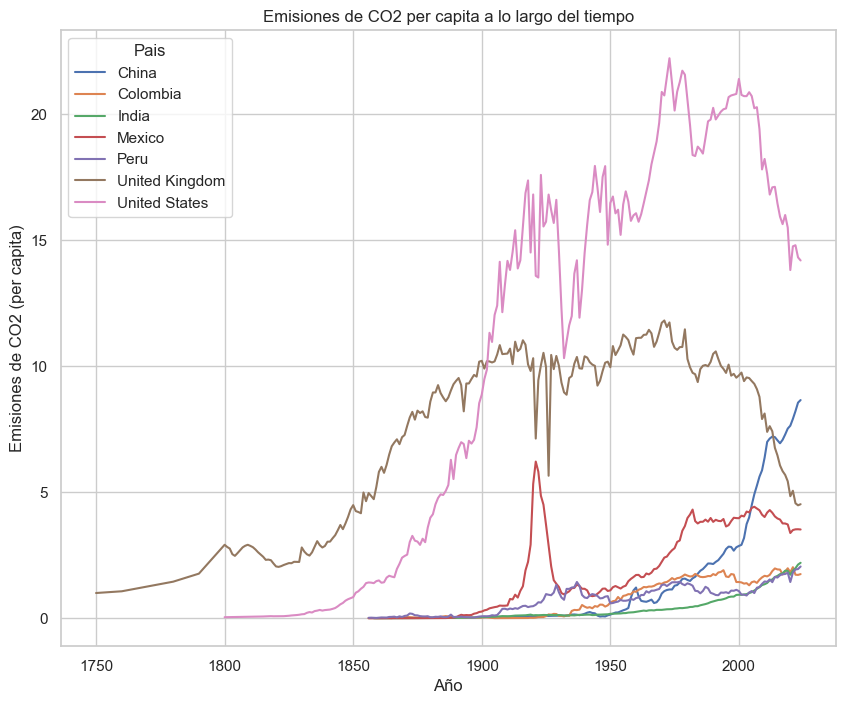

In [6]:
# Se crea un grafico de lineas utilizando seaborn para mostrar las emisiones de CO2 per capita a lo largo del tiempo para los paises seleccionados.
# Se usa matplotlib para configurar el tamaño del grafico, agregar titulos y etiquetas a los ejes, y mostrar la leyenda que indica a que pais corresponde cada linea.

plt.figure(figsize=(10,8))
sns.lineplot(data=filtered_data, x='Year', y='CO₂ emissions per capita', hue='Entity')
plt.title('Emisiones de CO2 per capita a lo largo del tiempo')
plt.xlabel('Año')
plt.ylabel('Emisiones de CO2 (per capita)')
plt.legend(title='Pais')
plt.show()

Esta gráfica de líneas muestra la evolución anual de las emisiones per cápita a lo largo del tiempo.

Hallazgos principales:

Estados Unidos presenta un crecimiento fuerte durante el siglo XX, alcanzando un pico cercano a 22 toneladas per cápita antes de disminuir en años recientes.

Reino Unido muestra emisiones elevadas desde el siglo XIX debido a su temprana industrialización, pero con una tendencia decreciente en el siglo XXI.

China muestra un crecimiento acelerado después de 2000, asociado con su expansión industrial.

México presenta un aumento moderado con picos asociados a periodos de crecimiento económico.

India, Colombia y Perú mantienen niveles bajos en comparación con las grandes economías, aunque con incrementos graduales.

Esta gráfica evidencia cómo los procesos de industrialización influyen directamente en las emisiones de carbono.

In [7]:
# Se agrega una nueva columna al DataFrame filtrando que representa la decada a la que corresponde cad año.
# Luego, se filtran los datos para incluir solo las decadas a partir de 1950.
# Por ultimo, se calcula el promedio de emisiones por cada decada para cada pais utilizando el metodo groupby() y mean(), y se muestra el resultado.

filtered_data.loc[:, 'Decade'] = (filtered_data['Year']//10)*10
decade_data = filtered_data[filtered_data['Decade'] >= 1950]
decade_avg = decade_data.groupby(['Entity', 'Decade'])['CO₂ emissions per capita'].mean().reset_index()

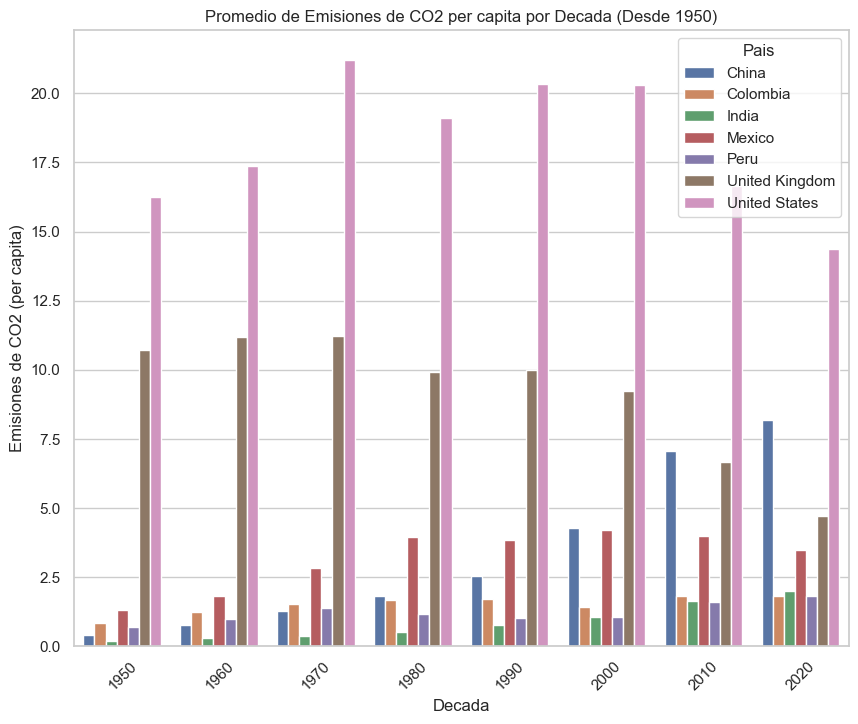

In [8]:
# Se crea una grafica de barras para mostrar el promedio de emisiones de CO2 per capita por decada para cada pais.

plt.figure(figsize=(10, 8))
sns.barplot(data=decade_avg, x='Decade', y='CO₂ emissions per capita', hue='Entity')
plt.xticks(rotation=45) #Rotar etiquetas del eje X
plt.title('Promedio de Emisiones de CO2 per capita por Decada (Desde 1950)')
plt.xlabel('Decada')
plt.ylabel('Emisiones de CO2 (per capita)')
plt.legend(title='Pais')
plt.show()

Esta gráfica de barras muestra el promedio de emisiones de CO₂ per cápita por década desde 1950 hasta 2020 para distintos países.

Los resultados evidencian diferencias importantes entre economías desarrolladas y países en desarrollo.

Principales hallazgos:

Estados Unidos presenta los valores más altos durante todo el periodo analizado, con emisiones superiores a 20 toneladas per cápita en varias décadas, aunque se observa una disminución hacia 2020.

Reino Unido muestra niveles altos en las primeras décadas, pero con una tendencia clara a la reducción en las últimas décadas.

China registra el crecimiento más acelerado, pasando de valores muy bajos en 1950 a más de 8 toneladas per cápita en 2020, reflejando su fuerte industrialización.

México muestra un crecimiento moderado hasta los años 2000 y posteriormente una ligera disminución.

Colombia, Perú e India mantienen niveles relativamente bajos durante todo el periodo, aunque con incrementos graduales.

En general, la gráfica muestra un crecimiento en las emisiones en países en desarrollo conforme avanza su industrialización, mientras que algunos países desarrollados muestran estabilización o reducción.

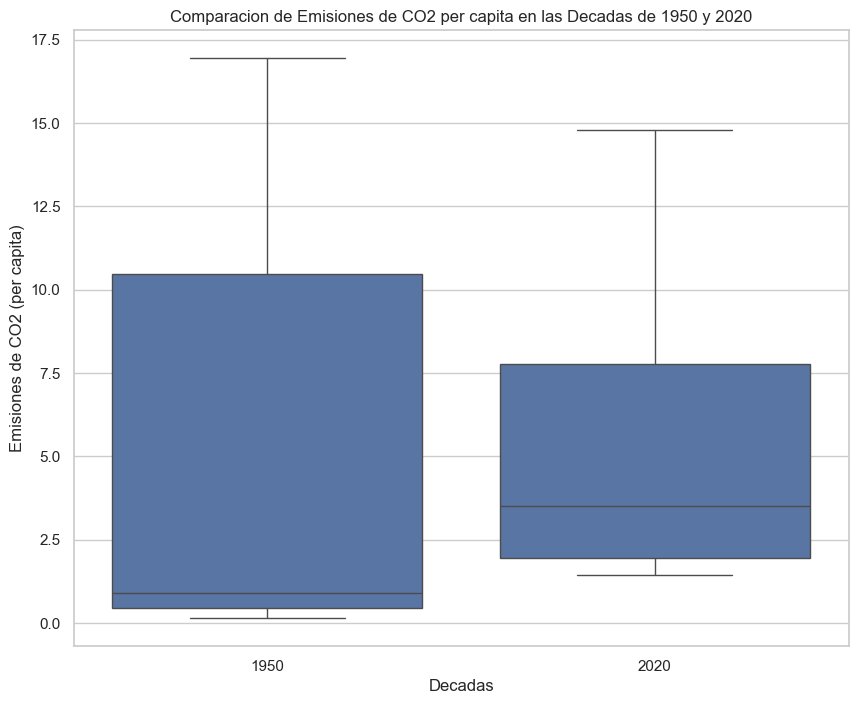

In [9]:
# Se filtran los datos para incluir solo las decadas de 1950 y 2020.
# Se crea una nueva columna 'Decade Label' para mostrar las decadas como etiquetas en el grafico.

decades_1950_2020 = filtered_data [filtered_data['Decade'].isin([1950, 2020])].copy()
decades_1950_2020.loc[:, 'Decade Label'] = decades_1950_2020['Decade'].astype(str)

# Se crea un grafico de cajas para comparar las emisiones de CO2 per capita entre las decadas de 1950 y 2020 para los paises seleccionados.

plt.figure(figsize=(10, 8))
sns.boxplot(data = decades_1950_2020, x = 'Decade Label', y = 'CO₂ emissions per capita')
plt.title('Comparacion de Emisiones de CO2 per capita en las Decadas de 1950 y 2020')
plt.xlabel('Decadas')
plt.ylabel('Emisiones de CO2 (per capita)')
plt.show()

Esta gráfica de cajas compara la distribución de emisiones per cápita entre las décadas de 1950 y 2020.

Resultados principales:

En 1950, la mayoría de los países presentaban emisiones relativamente bajas, con una mediana cercana a valores inferiores a 1 tonelada per cápita.

Sin embargo, existían valores extremos altos, principalmente correspondientes a países altamente industrializados.

En 2020, la distribución se desplaza hacia valores mayores, lo que indica un aumento global de las emisiones promedio.

También se observa una mayor dispersión, reflejando las diferencias entre países altamente industrializados y aquellos en desarrollo.

Esto sugiere que, aunque algunos países han reducido sus emisiones, el crecimiento económico global ha incrementado las emisiones promedio en muchos países.

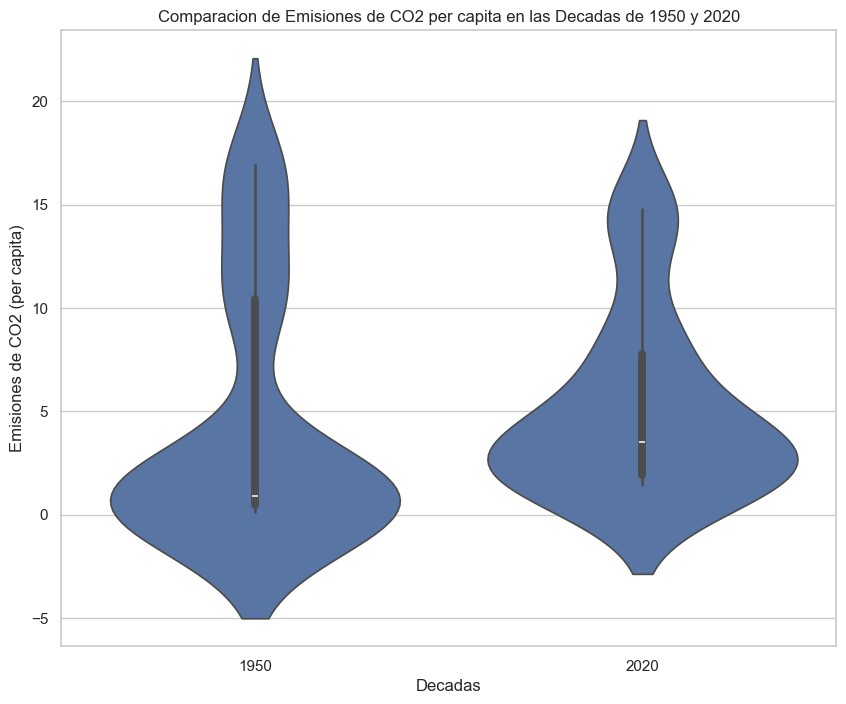

In [10]:
# Se crea un grafico de violines para comparar la distribucion de las emisiones de CO2 per capita entre las decadas de 1950 y 2020 para los paises seleccionados.

plt.figure(figsize=(10, 8))
sns.violinplot(data = decades_1950_2020, x = 'Decade Label', y = 'CO₂ emissions per capita')
plt.title('Comparacion de Emisiones de CO2 per capita en las Decadas de 1950 y 2020')
plt.xlabel('Decadas')
plt.ylabel('Emisiones de CO2 (per capita)')
plt.show()

El gráfico de violín compara la densidad de distribución de emisiones entre las décadas de 1950 y 2020.

Interpretación:

En 1950, la mayor concentración de valores se encuentra en niveles bajos de emisiones.

En 2020, la distribución se desplaza hacia valores más altos, mostrando un incremento en la densidad de emisiones intermedias y altas.

También se observa una mayor dispersión, indicando que algunos países han incrementado considerablemente sus emisiones mientras otros las han reducido.

Este gráfico permite visualizar con mayor detalle cómo se distribuyen los datos y dónde se concentran los valores más frecuentes.

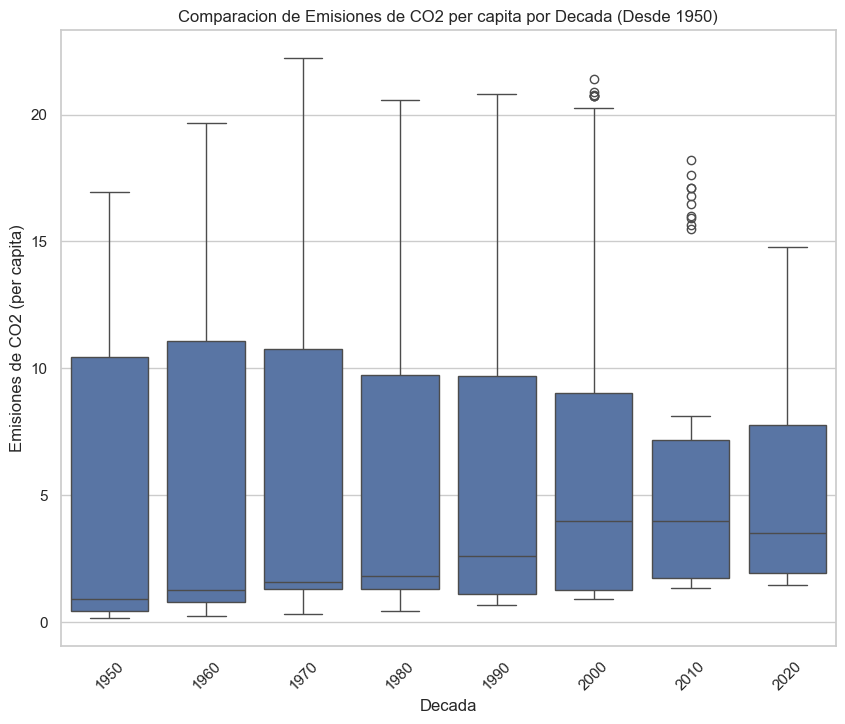

In [11]:
# Se crea una variable que contiene los datos de todas las decadas a partir de 1950.

all_decades_data = filtered_data[filtered_data['Decade'] >= 1950]

# Con la variable creada, se genera un grafico de cajas para comparar las emisiones de CO2 per capita entre todas las deadas a partir de 1950 para los paises seleccionados.

plt.figure(figsize=(10, 8))
sns.boxplot(data = all_decades_data, x = 'Decade', y = 'CO₂ emissions per capita')
plt.title('Comparacion de Emisiones de CO2 per capita por Decada (Desde 1950)')
plt.xlabel('Decada')
plt.ylabel('Emisiones de CO2 (per capita)')
plt.xticks(rotation= 45)
plt.show()

Este conjunto de diagramas de caja muestra cómo ha cambiado la distribución de emisiones de CO₂ per cápita en cada década desde 1950.

Observaciones importantes:

La mediana de las emisiones aumenta gradualmente con el tiempo, indicando un crecimiento global en las emisiones.

Las décadas más recientes muestran mayor variabilidad, lo que refleja diferencias más marcadas entre países.

Aparecen valores atípicos en las décadas posteriores, asociados principalmente con países con niveles muy altos de emisiones.

Este patrón sugiere que el desarrollo industrial y económico ha incrementado las emisiones globales, pero de forma desigual entre países.

In [12]:
# Se crea una tabla pivote para mostrar las emisiones de CO2 per capita por año para cada pais seleccionado.

pivot_data = filtered_data.pivot(index='Year', columns='Entity', values='CO₂ emissions per capita')
pivot_data.head()

Entity,China,Colombia,India,Mexico,Peru,United Kingdom,United States
Year,,,,,,,
1750,NaN,NaN,NaN,NaN,NaN,1.001912,NaN
1760,NaN,NaN,NaN,NaN,NaN,1.070363,NaN
1770,NaN,NaN,NaN,NaN,NaN,1.262799,NaN
1780,NaN,NaN,NaN,NaN,NaN,1.452038,NaN
1790,NaN,NaN,NaN,NaN,NaN,1.770789,NaN


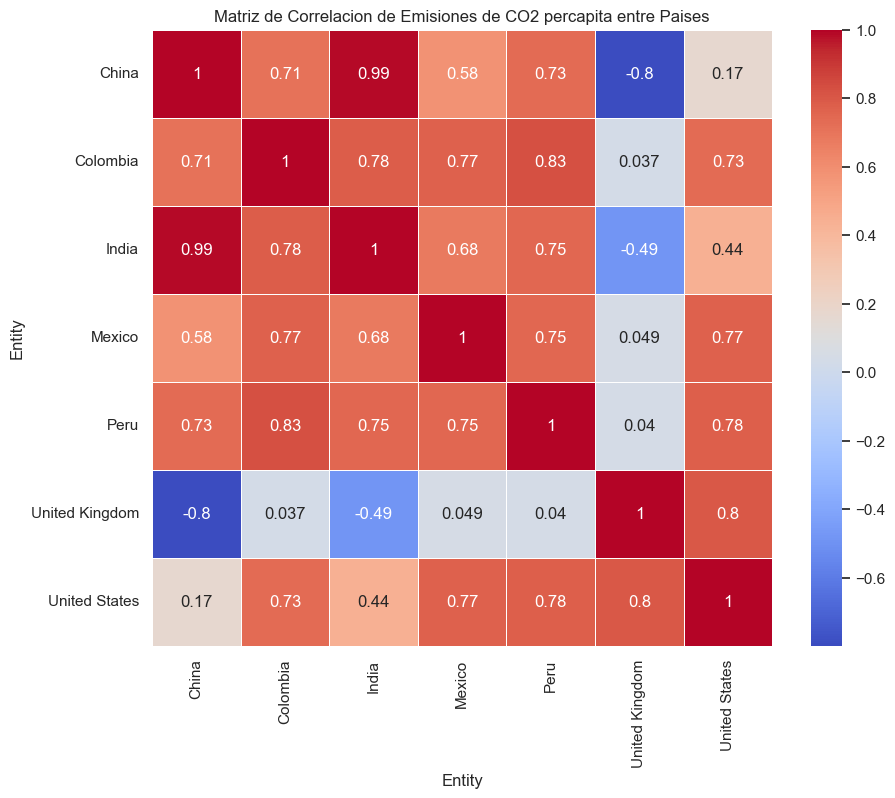

In [13]:
# Se calcula la matriz de correlacion entre las emisiones de los paises utilizando el metodo corr() de pandas, que calcula la correlacion entre las columnas del DataFrame pivoteado.

correlation_matrix = pivot_data.corr()

# Se crea un mapa de calor utilizando seaborn para visualizar la matriz de correlacion entre las emisiones de CO2 per capita entre los paises seleccionados.

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlacion de Emisiones de CO2 percapita entre Paises')
plt.show()

La matriz de correlación muestra el grado de relación entre las tendencias de emisiones de distintos países.

Principales resultados:

Existe una alta correlación positiva entre China e India, lo que indica que ambos países han seguido trayectorias de crecimiento similares en sus emisiones.

Colombia, México y Perú presentan correlaciones positivas relativamente altas entre sí, reflejando patrones regionales similares de desarrollo económico.

Estados Unidos y Reino Unido también presentan correlaciones altas, ya que ambos países experimentaron industrialización temprana y posteriormente procesos de reducción de emisiones.

Algunas correlaciones negativas, como entre China y Reino Unido, reflejan trayectorias opuestas, donde uno incrementa emisiones mientras el otro las reduce.

La matriz permite identificar patrones compartidos de desarrollo industrial y transición energética.

In [14]:
# Se crea una funcion que resive dos paises
def scatter_plot_dynamic(country1, country2, trendline=False):
    # Se crea una condicion para mostrar un mensaje en caso de que ambos paises elejidos sean iguales.
    if country1 == country2:
        print('Selecione dos paises diferentes para comparar.')
        return
    
    # Se filtran los datos para los dos paises seleccionados
    data1 = filtered_data[filtered_data['Entity'] == country1]
    data2 = filtered_data[filtered_data['Entity'] == country2]

    # Se combinan los datos en un solo dataframe por año
    merged_data = data1[['Year', 'CO₂ emissions per capita']].merge(
        data2[['Year', 'CO₂ emissions per capita']],
        on='Year', suffixes=(f"_{country1}", f"_{country2}")
    )

    # Calcular el coeficiente de correlacion
    correlation = merged_data[f"CO₂ emissions per capita_{country1}"].corr(
        merged_data[f"CO₂ emissions per capita_{country2}"]
    )

    # Se grafica el diagra,a de dispersion
    plt.figure(figsize=(8, 6)) 
    sns.scatterplot(data=merged_data,
                    x=f"CO₂ emissions per capita_{country1}",
                    y=f"CO₂ emissions per capita_{country2}")
    
    plt.title(f"Relacion entre Emisiones de CO2 percapita de {country1} y {country2} \nCoeficiente de Correlacion: {correlation}")
    plt.xlabel(f"Emisiones de CO2 per capita - {country1}")
    plt.ylabel(f"Emisiones de CO2 per capita - {country2}")
    
    # Se agrega la linea de tendencia
    if trendline:
        # Se calcula la linea de tendencia
        x = merged_data[f"CO₂ emissions per capita_{country1}"]
        y = merged_data[f"CO₂ emissions per capita_{country2}"]
        m, b = np.polyfit(x, y, 1)
        plt.plot(x, m * x+b, color = 'red', linestyle = '--', label = f"Tendencia (y = {m:.2f}x + {b:.2f})")
        plt.legend()

    plt.show()

In [ ]:
# Se crea un widget interactivo para seleccionar los paises y la opcion de lineade tendencia.
interact(scatter_plot_dynamic,
         country1 = widgets.Dropdown(options=countries, description='Pais 1', value='United States'),
         country2 = widgets.Dropdown(options=countries, description='Pais 2', value='Mexico'),
         trendline = widgets.Checkbox(values=False, description='Mostrar linea de tendencia'))

interactive(children=(Dropdown(description='Pais 1', options=('United States', 'China', 'India', 'United Kingd…

<function __main__.scatter_plot_dynamic(country1, country2, trendline=False)>

# Visualización interactiva de correlación entre países

El proyecto incluye una visualización interactiva que permite analizar la relación entre las emisiones de CO₂ per cápita de dos países a lo largo del tiempo.

El usuario puede:

Seleccionar dos países desde menús desplegables.

Visualizar un diagrama de dispersión entre sus emisiones de CO₂ per cápita.

Calcular automáticamente el coeficiente de correlación entre ambas series.

Opcionalmente mostrar una línea de tendencia para identificar la relación entre las variables.

Esta herramienta permite explorar cómo las emisiones de distintos países se relacionan entre sí y detectar patrones de desarrollo o industrialización similares.

# Ejemplo de análisis: Relación entre emisiones de CO₂ per cápita de Estados Unidos y México

![texto alternativo](correlacion.png)

En esta visualización interactiva se comparan las emisiones de CO₂ per cápita de Estados Unidos y México mediante un gráfico de dispersión.

Cada punto representa un año, donde:

El eje X muestra las emisiones de CO₂ per cápita de Estados Unidos.

El eje Y muestra las emisiones de CO₂ per cápita de México.

El coeficiente de correlación obtenido es 0.77, lo que indica una correlación positiva moderada entre las emisiones de ambos países. Esto significa que, en general, cuando las emisiones en Estados Unidos aumentan, las emisiones en México también tienden a aumentar.

La línea roja punteada representa la línea de tendencia, la cual muestra la relación general entre ambas variables.

Este tipo de visualización permite analizar cómo se relacionan las emisiones entre diferentes países y explorar posibles patrones en su evolución a lo largo del tiempo.

----------------------------------------------------------------------------------------------------
### Cómo usar la visualización

Ejecutar el notebook o script del proyecto.

Seleccionar dos países desde los menús desplegables.

Analizar el diagrama de dispersión generado.

Activar la opción "Mostrar línea de tendencia" para visualizar la relación lineal entre las variables.

Cada punto del gráfico representa un año específico y muestra la relación entre las emisiones per cápita de ambos países.

---------------------------------------------------------------------------------------------------------------

### Interpretación del gráfico

Correlación cercana a 1 → ambos países siguen tendencias similares.

Correlación cercana a 0 → no existe relación clara.

Correlación negativa → cuando uno aumenta emisiones, el otro disminuye.

El gráfico permite identificar patrones de desarrollo industrial y cambios en las políticas energéticas a lo largo del tiempo.